In [83]:
#relative path for importing crime data
import pandas as pd
from pandas import read_csv
import os

df = (pd.read_csv('../../02_activities/assignments/neighbourhood-crime-rates - 4326.csv'))
df

,_id,AREA_NAME,HOOD_ID,ASSAULT_2014,ASSAULT_2015,ASSAULT_2016,ASSAULT_2017,ASSAULT_2018,ASSAULT_2019,ASSAULT_2020,...,THEFTOVER_RATE_2017,THEFTOVER_RATE_2018,THEFTOVER_RATE_2019,THEFTOVER_RATE_2020,THEFTOVER_RATE_2021,THEFTOVER_RATE_2022,THEFTOVER_RATE_2023,THEFTOVER_RATE_2024,POPULATION_2024,geometry
0,1,South Eglinton-Davisville,174,55,56,66,73,74,62,74,...,4.915454,14.018037,13.369579,17.041582,24.314138,11.784578,29.877502,21.895412,27403,"{""coordinates"": [[[[-79.3863542900264, 43.6978..."
1,2,North Toronto,173,53,57,47,61,66,84,80,...,15.913431,36.767410,27.324270,44.651402,11.916821,22.527596,36.672256,30.109901,19927,"{""coordinates"": [[[[-79.3974398976879, 43.7069..."
2,3,Dovercourt Village,172,62,65,92,105,106,113,91,...,22.389730,30.136368,30.436768,23.027327,15.363343,30.355923,22.052338,51.139683,13688,"{""coordinates"": [[[[-79.4341164165158, 43.6601..."
3,4,Junction-Wallace Emerson,171,164,159,171,161,163,186,171,...,24.498795,36.736195,16.320536,36.677807,32.307568,31.404570,33.652409,47.570259,27328,"{""coordinates"": [[[[-79.4387032547807, 43.6676..."
4,5,Yonge-Bay Corridor,170,387,521,481,602,576,660,377,...,290.095306,353.045013,489.814972,263.812469,188.747726,348.980438,329.405792,289.715118,16568,"{""coordinates"": [[[[-79.3840431592607, 43.6449..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,154,West Humber-Clairville,1,289,306,291,301,314,255,248,...,167.843506,146.991013,186.738678,160.178482,152.684708,169.524490,211.275146,201.148666,37783,"{""coordinates"": [[[[-79.5903745028226, 43.7340..."
154,155,Black Creek,24,222,226,279,246,199,216,269,...,76.205849,35.972839,40.599060,72.378540,40.549675,35.752590,56.457916,52.087856,23038,"{""coordinates"": [[[[-79.5191491527649, 43.7739..."
155,156,Pelmo Park-Humberlea,23,58,45,59,53,73,77,54,...,54.190750,35.625221,61.533051,86.767899,17.015484,74.812965,47.885075,55.009823,12725,"{""coordinates"": [[[[-79.532254418425, 43.73505..."
156,157,Humbermede,22,105,128,106,150,107,150,84,...,42.826553,60.034821,47.139236,57.853630,73.247688,49.290760,52.099613,40.778877,19618,"{""coordinates"": [[[[-79.5281298918329, 43.7442..."


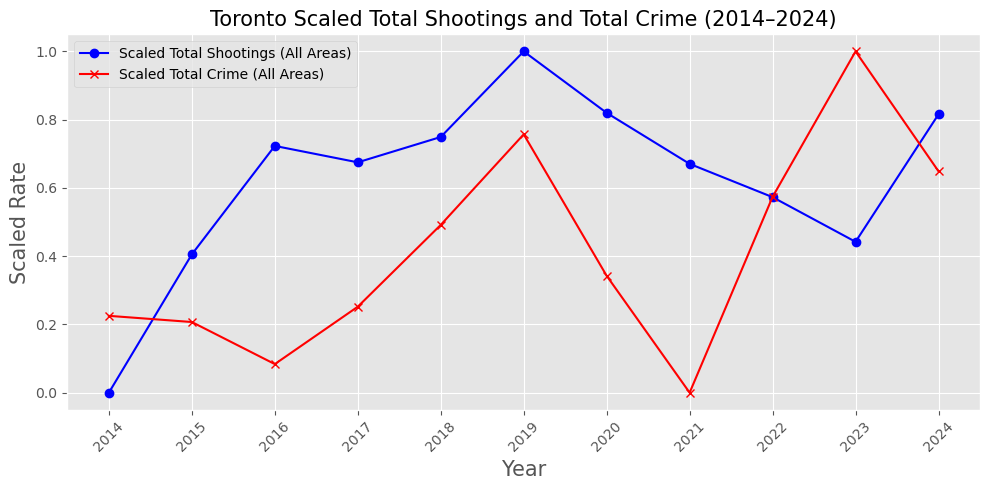

In [97]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Select total shooting count columns (e.g., 'SHOOTING_2021', 'SHOOTING_2022', etc.)
shooting_cols = [col for col in df.columns if col.startswith('SHOOTING_')]

# Extract years from column names (e.g., '2021', '2022', etc.)
years = sorted(set([int(col.split('_')[-1]) for col in shooting_cols]))  # List of years

# Initialize a list to store the total shootings for each year
y_shootings = []

# Sum across all areas (rows) for each year column (total shootings)
for year in years:
    # Get all shooting columns for the current year
    cols_for_year = [col for col in shooting_cols if f'_{year}' in col]
    
    # Sum the shooting columns for this year across all areas (rows)
    total_shootings = df[cols_for_year].sum(axis=0).sum()  # Sum across rows for all columns in the year
    y_shootings.append(total_shootings)

# Calculate the total crime for each year
total_crime_per_year = []

# Loop over each year and sum the crime columns (e.g., ASSAULT_RATE_2014, HOMICIDE_RATE_2014, etc.)
for year in years:
    # Identify crime columns for the current year
    crime_cols_for_year = [col for col in df.columns if f'_{year}' in col and any(crime_type in col for crime_type in ['ASSAULT', 'AUTOTHEFT', 'BIKETHEFT', 'BREAKENTER', 'HOMICIDE', 'ROBBERY', 'SHOOTING', 'THEFTFROMMV', 'THEFTOVER'])]
    
    # Sum the crime columns for this year across all areas (rows)
    total_crime = df[crime_cols_for_year].sum(axis=0).sum()  # Sum across rows for all columns in the year
    total_crime_per_year.append(total_crime)

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Scale total shootings and total crime rates to the range [0, 1]
scaled_shootings = scaler.fit_transform([[y] for y in y_shootings])  # Reshaping for scaler
scaled_total_crime = scaler.fit_transform([[crime] for crime in total_crime_per_year])  # Reshaping for scaler

# Convert them back to a 1D array
scaled_shootings = scaled_shootings.flatten()
scaled_total_crime = scaled_total_crime.flatten()

# Plot
plt.style.use('tableau-colorblind10')  # Use a colorblind-friendly palette
fig, ax = plt.subplots(figsize=(10, 5))  # Use subplots to get the axes

# Plot the scaled total shootings for each year
ax.plot(years, scaled_shootings, marker='o', label='Scaled Total Shootings (All Areas)', color='blue')

# Plot the scaled total crime for each year
ax.plot(years, scaled_total_crime, marker='x', label='Scaled Total Crime (All Areas)', color='red')

# Labels and Title
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Scaled Rate', fontsize=15)
ax.set_title('Toronto Scaled Total Shootings and Total Crime (2014–2024)', fontsize=15)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

# Add legend
ax.legend()

# Tight layout for better spacing
plt.tight_layout()

# Export the plot to the specified directory
plt.savefig('../../02_activities/assignments/scaled_total_shootings_plot.png', format='png')

# Show plot
plt.show()
